# Merge And Complements

This notebook is the third step in the operator sequence. The first notebook introduced unary decompositions. The second notebook introduced composition and additive unions. Here we focus on three operators that transform an existing decomposition into a contrasting or aggregated view: `merge`, `complement`, and `edge_complement`.

Previous: [02 Composition And Add](./example_abstract_graph_operators_02_composition_and_add.ipynb)  
Next: [04 Filters And Selection](./example_abstract_graph_operators_04_filters_and_selection.ipynb)

## What you will see

We will focus on three ideas:

1. `merge()` collapses many mapped subgraphs into one aggregate mapped subgraph.
2. `complement()` keeps the nodes outside the current mapped subgraph.
3. `edge_complement()` keeps the base-graph edges that are missing from the current mapped subgraph.

In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import networkx as nx
from IPython.core.display import HTML
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')


In [3]:
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display, display_decomposition_graph, display_graph, display_mappings
from abstractgraph.operators import *


def draw(graph, decomposition_function, *, nbits=11, size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(graph, decomposition_function=decomposition_function, nbits=nbits)
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag


## The same toy graph

We reuse the same toy graph as notebooks 01 and 02 so the effect comes from the operators, not from a different graph.

Graph with 8 nodes and 9 edges


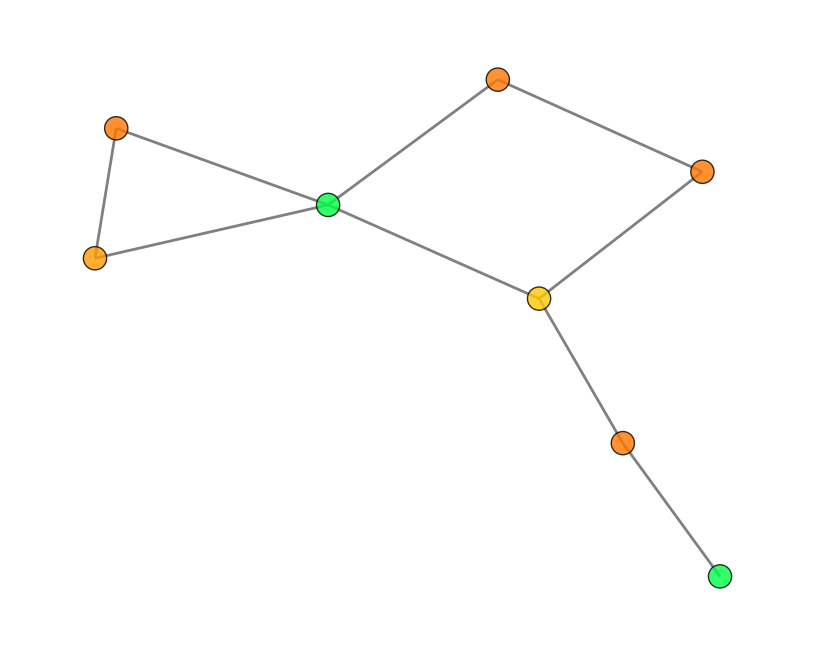

In [4]:
graph = nx.Graph()
graph.add_nodes_from([
    (0, {'label': 'C'}),
    (1, {'label': 'C'}),
    (2, {'label': 'O'}),
    (3, {'label': 'N'}),
    (4, {'label': 'C'}),
    (5, {'label': 'S'}),
    (6, {'label': 'C'}),
    (7, {'label': 'O'}),
])
graph.add_edges_from([
    (0, 1), (1, 2), (2, 3), (3, 0),
    (2, 4), (4, 5), (5, 2),
    (3, 6), (6, 7),
])

print(graph)
display_graph(graph)


## `merge()` after a mixed decomposition

A useful pattern is to build several mapped subgraphs and then collapse them into one combined interpretation node. Here we start with cycles and trees, connect overlapping mapped subgraphs, and then merge them.

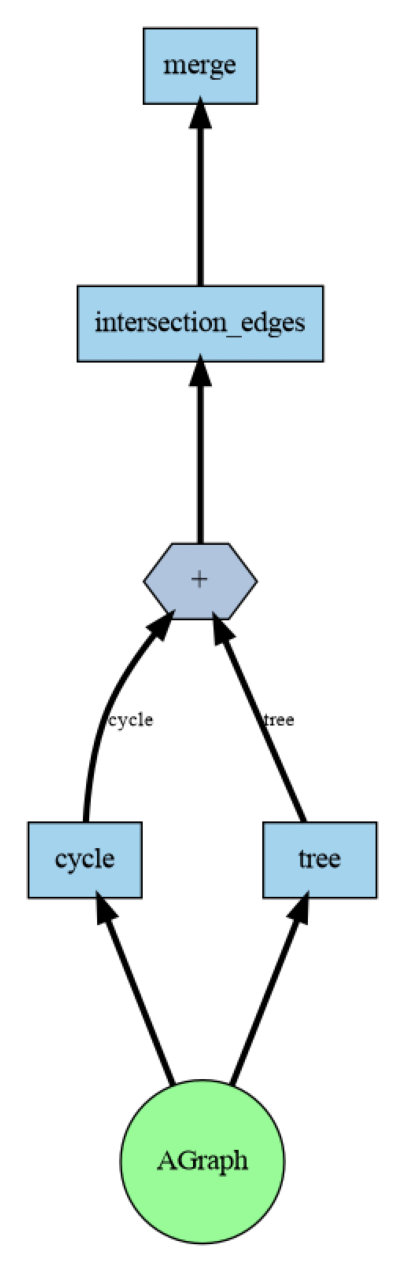

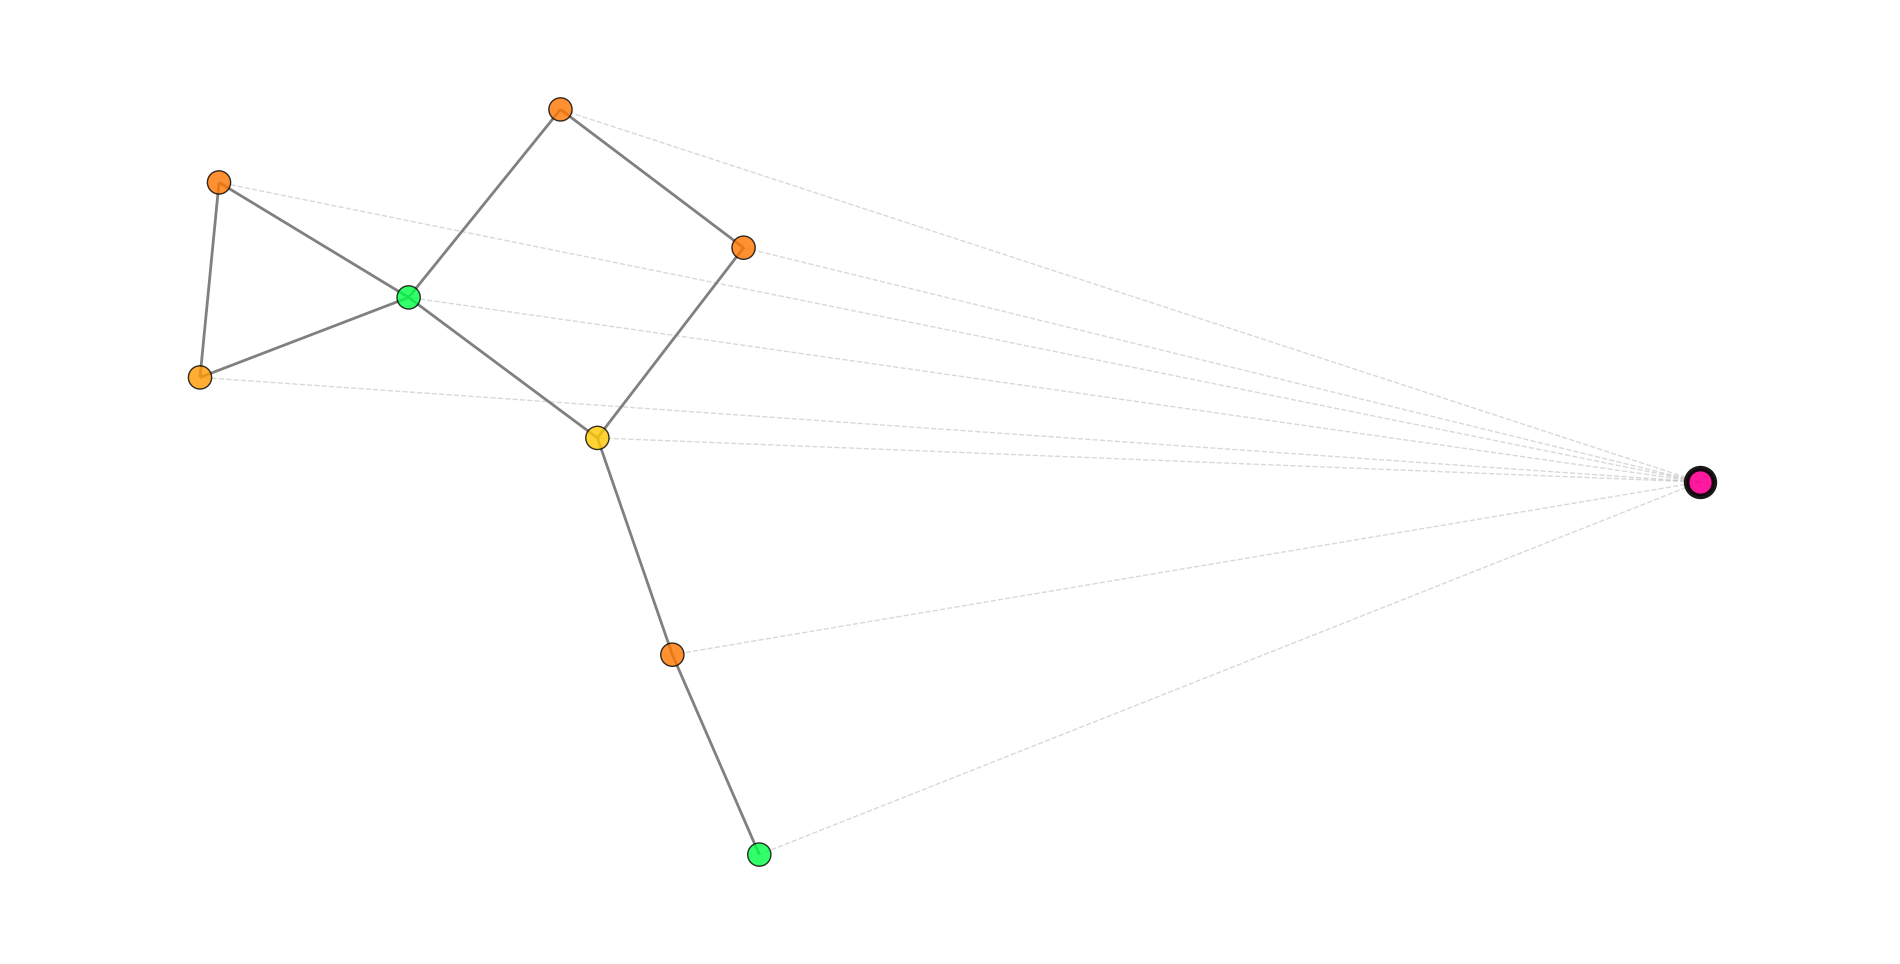

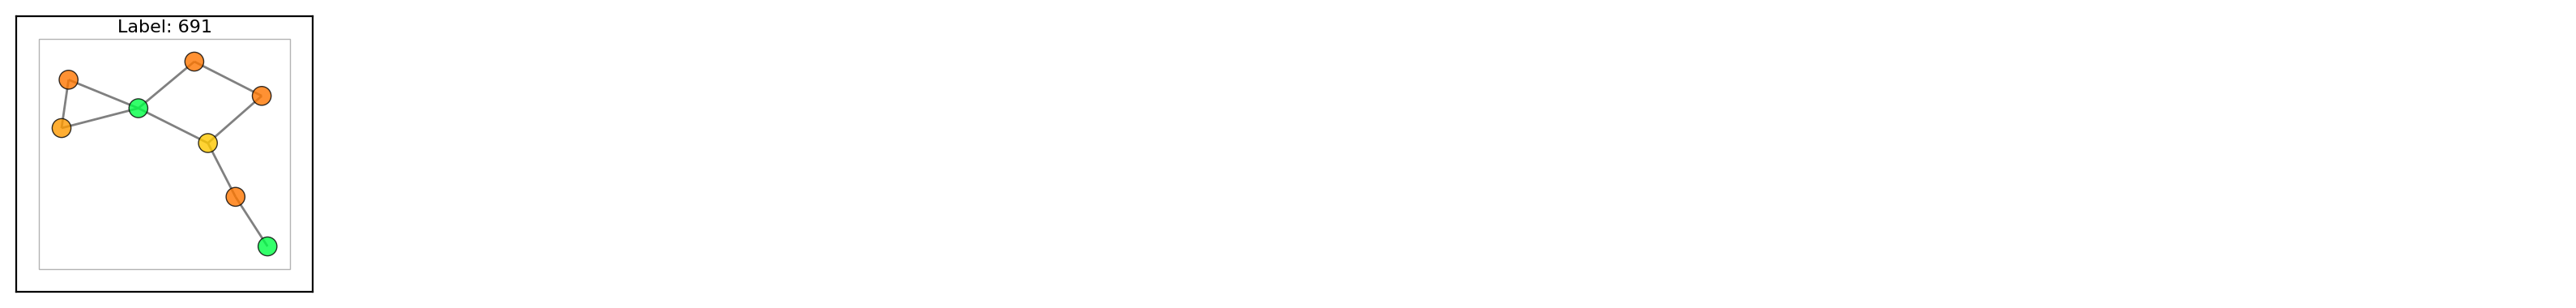

In [5]:
df = compose(merge(), intersection_edges(), add(cycle(), tree()))
merged_cycle_tree_ag = draw(graph, df)

## `merge(use_edges=True)` keeps the union of edges

The edge-aware merge is helpful when the decomposition emits overlapping edge motifs and you want one aggregate edge-induced subgraph.

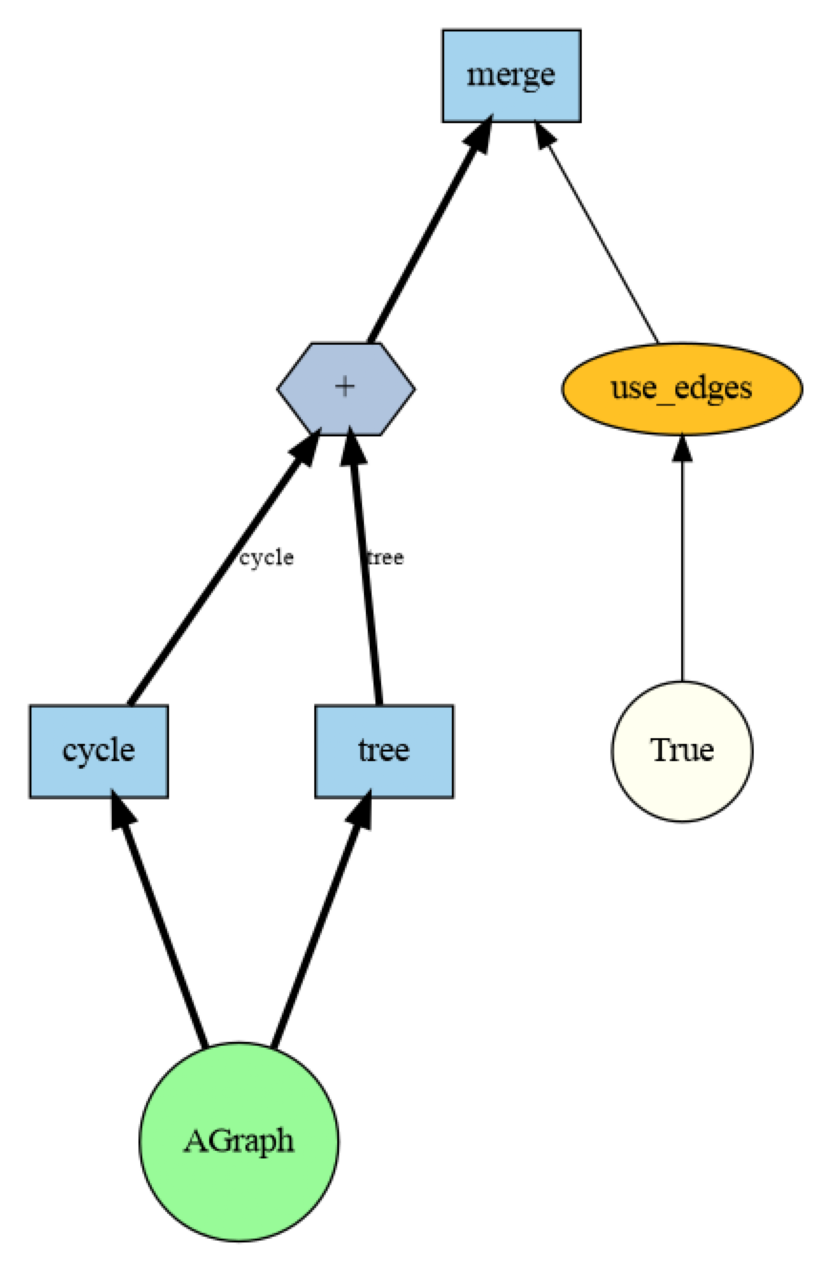

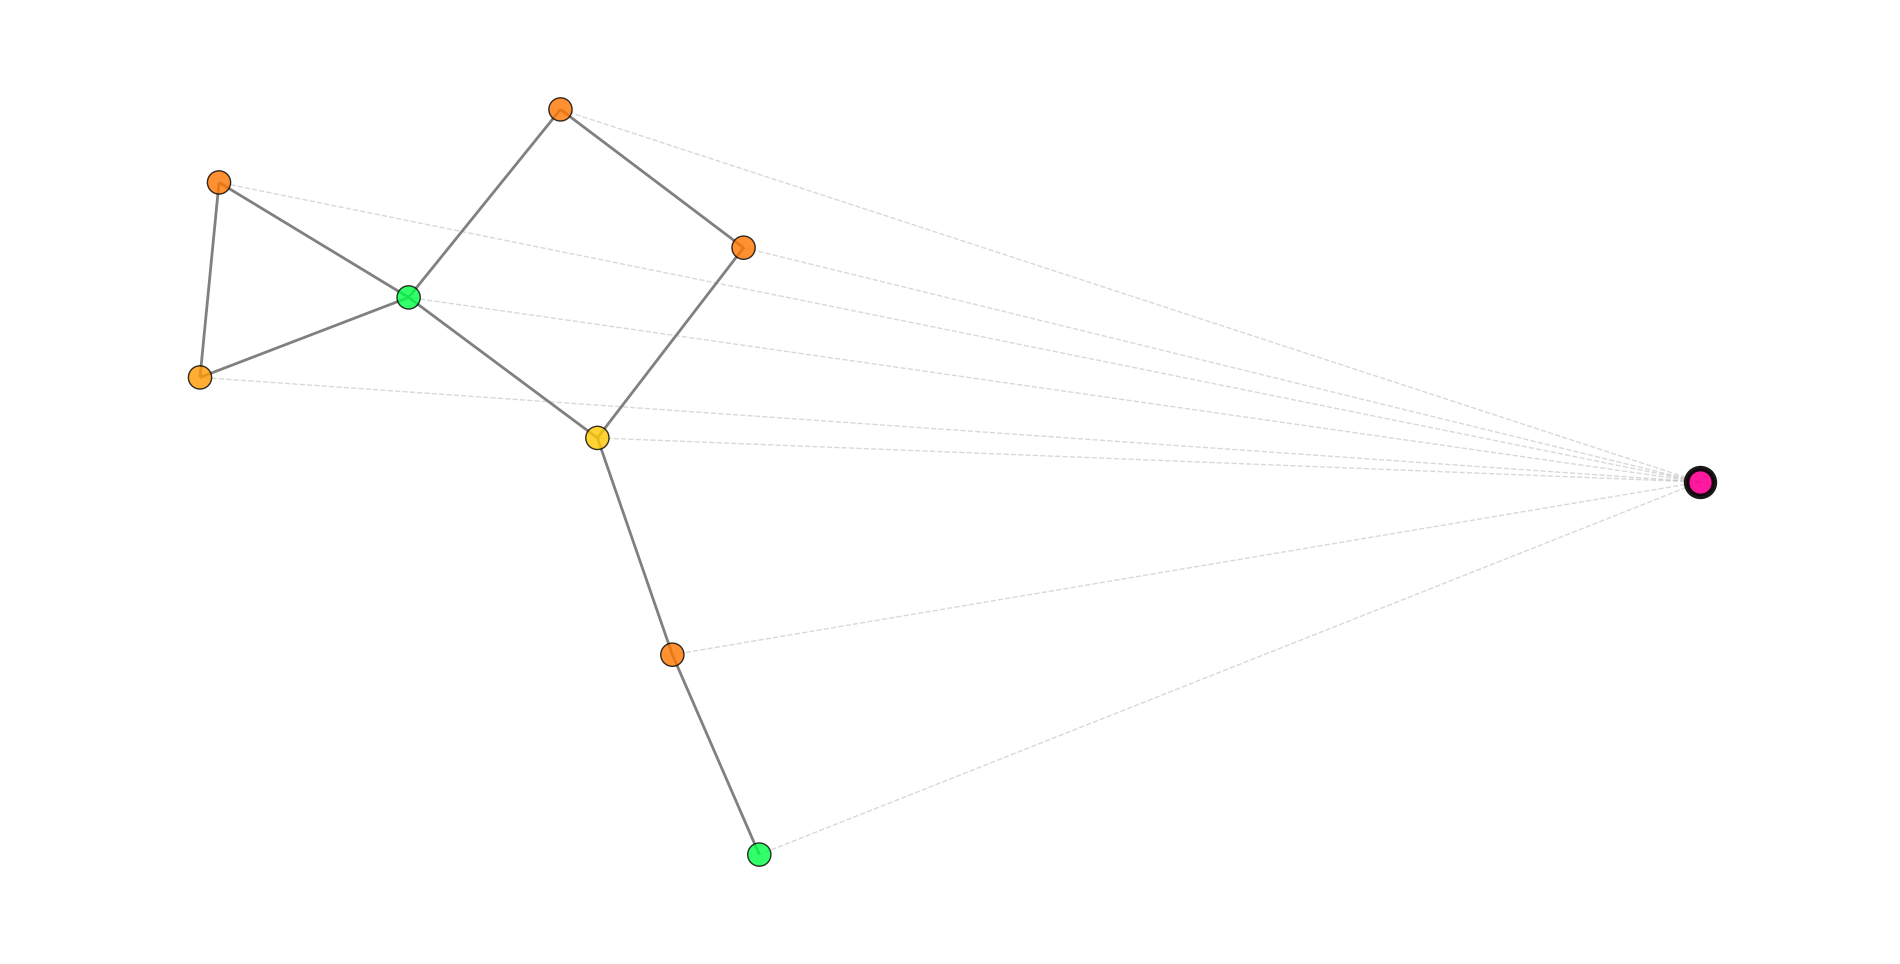

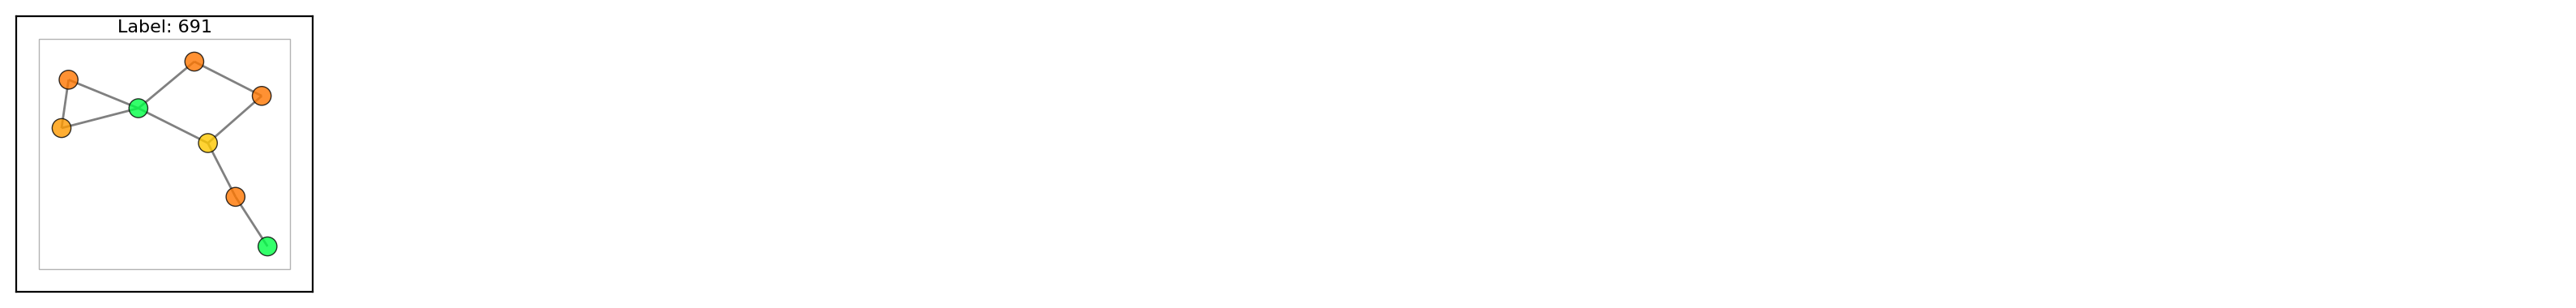

In [6]:
df = compose(merge(use_edges=True), add(cycle(), tree()))
merged_edges_ag = draw(graph, df)

## `complement()` gives the outside view

`complement()` is easiest to read after a decomposition with a clear motif. Here we extract the triangle and then show the nodes that live outside that clique.

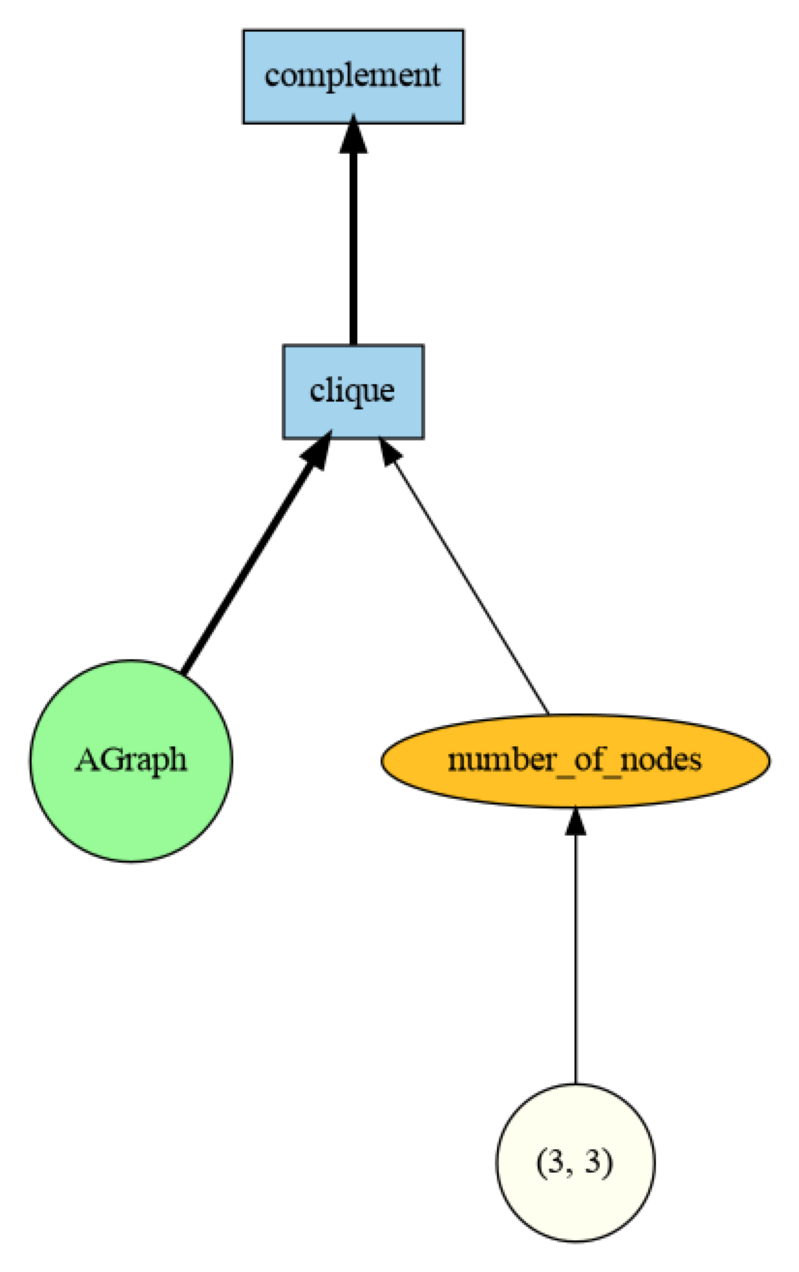

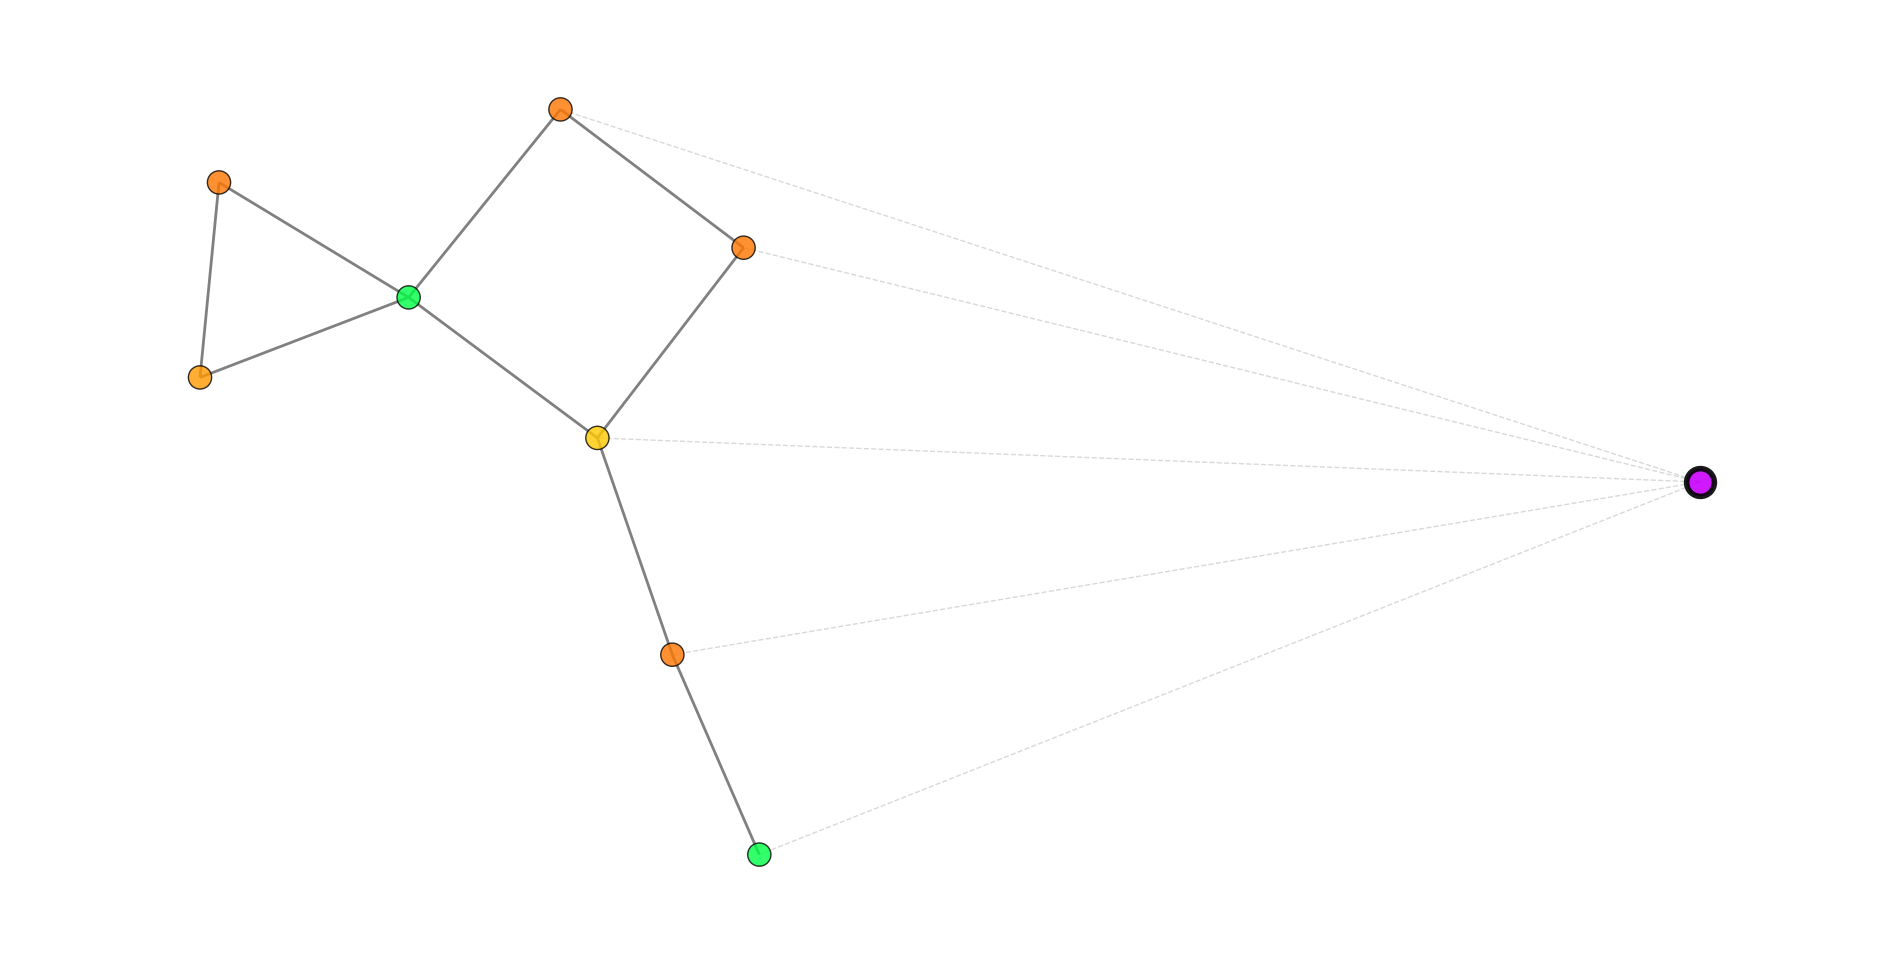

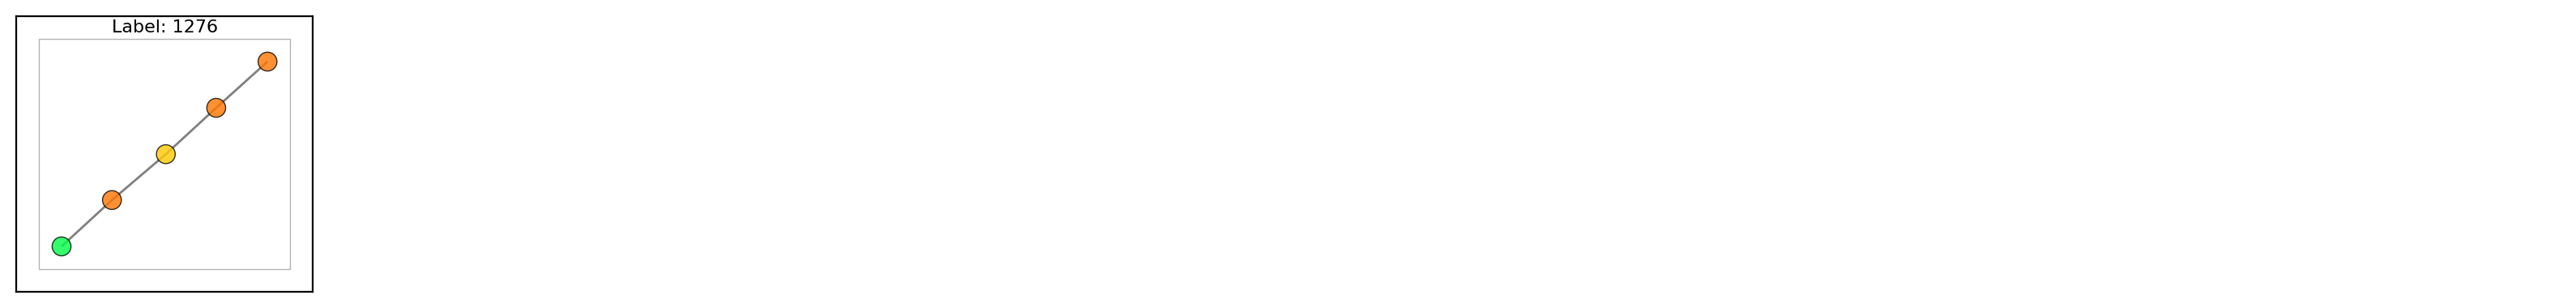

In [7]:
df = compose(complement(), clique(number_of_nodes=(3, 3)))
complement_ag = draw(graph, df)

## `edge_complement()` keeps the missing edges

Unlike `complement()`, which complements node sets, `edge_complement()` keeps every base-graph edge that is not already present in the current mapped subgraph.

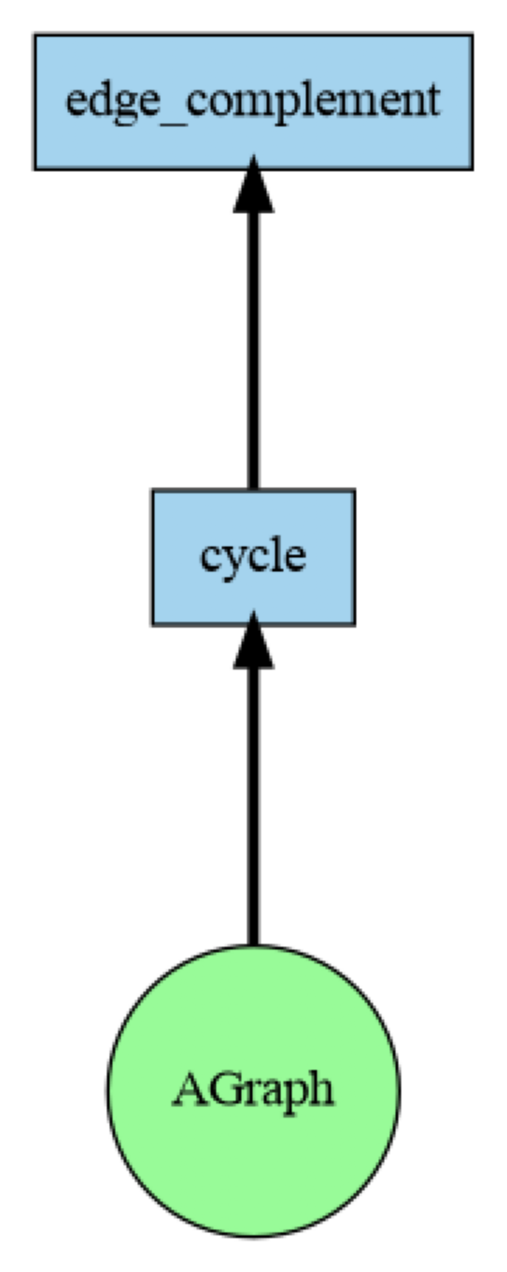

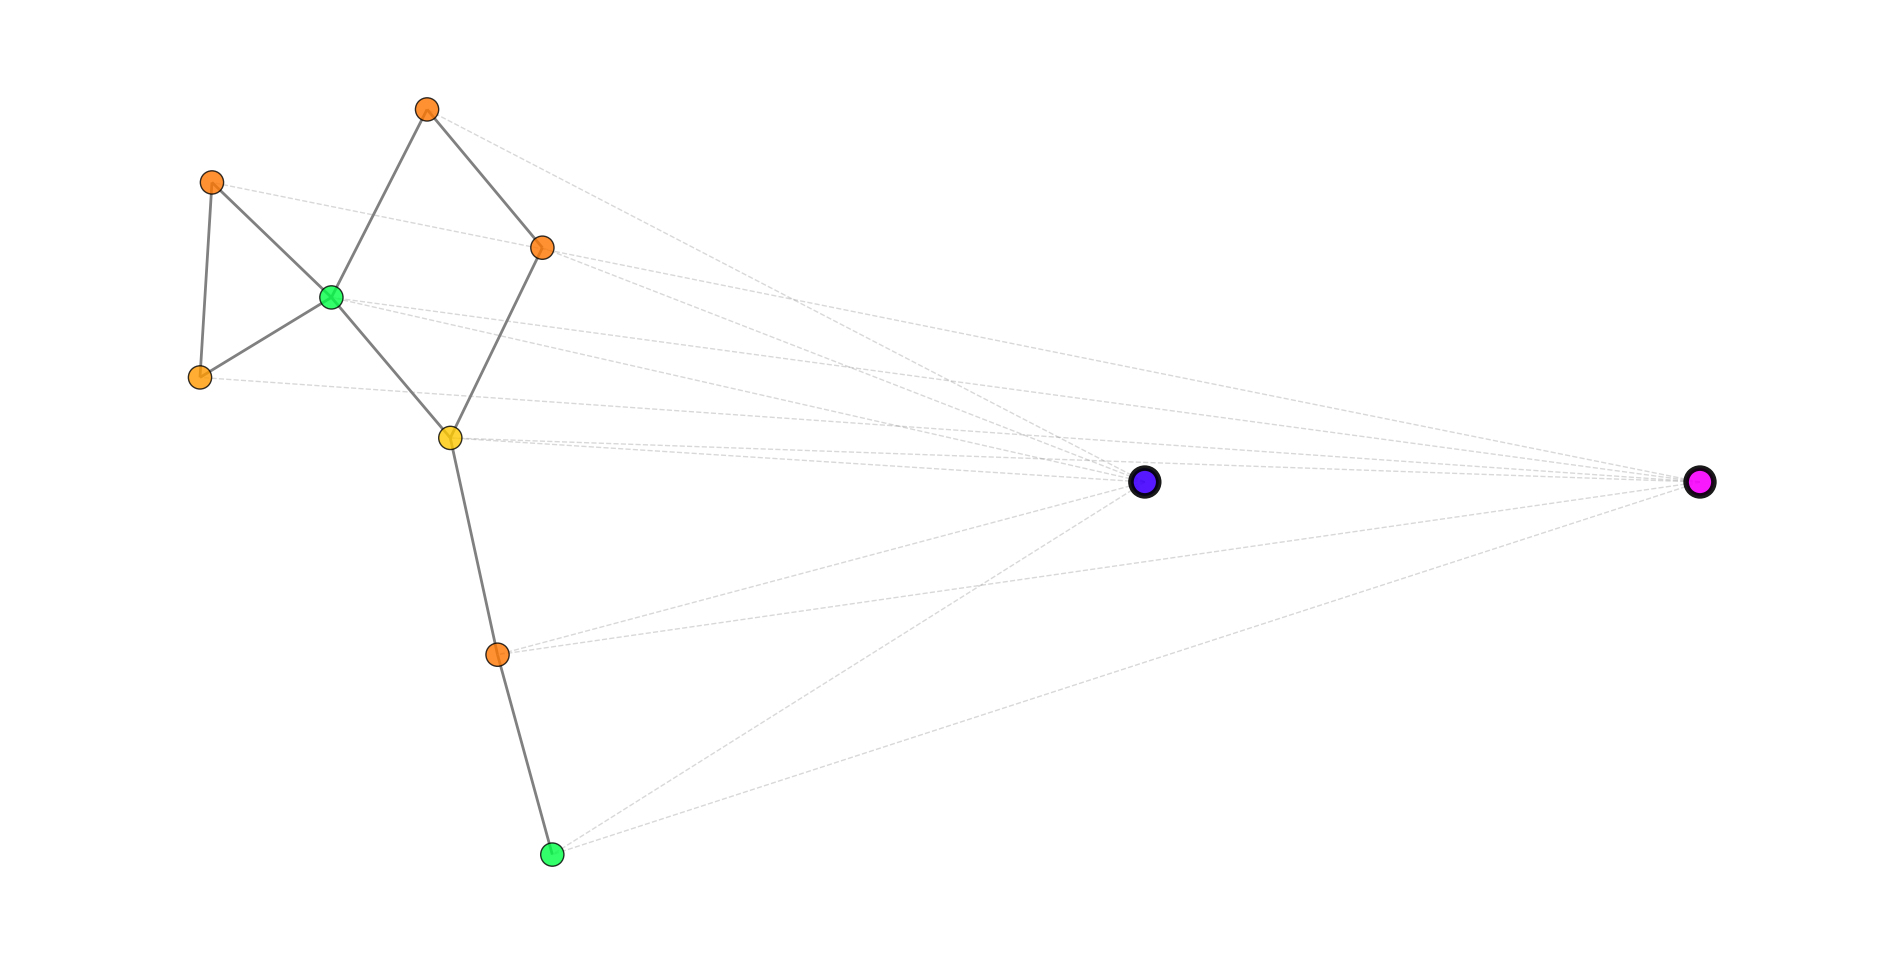

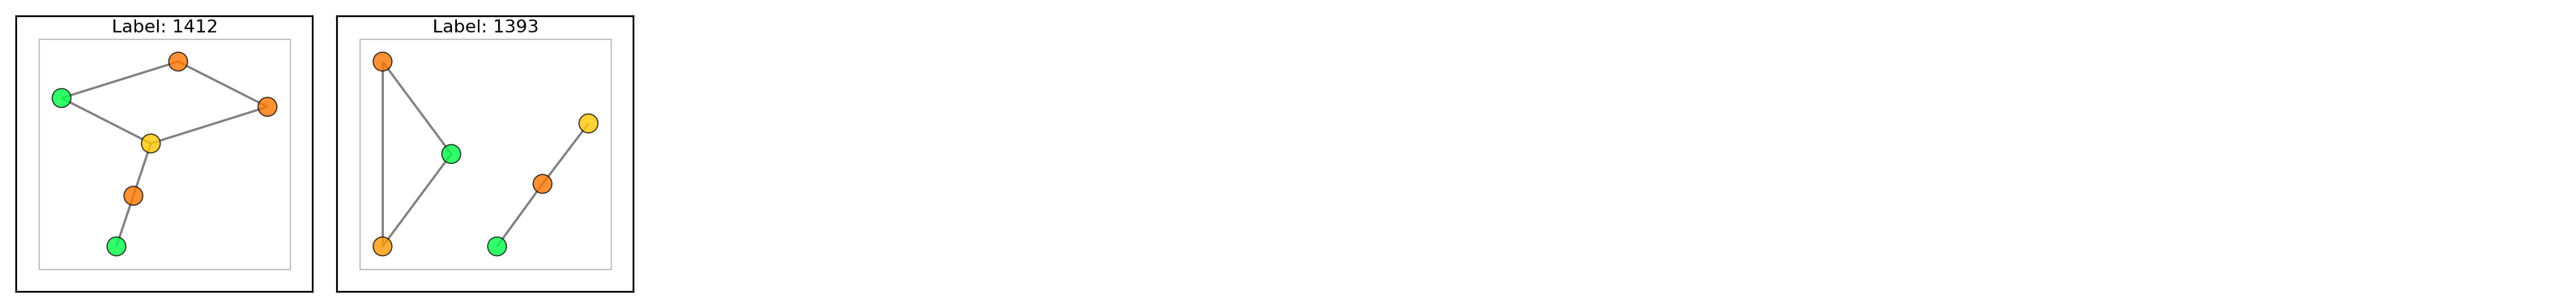

In [8]:
df = compose(edge_complement(), cycle())
edge_complement_ag = draw(graph, df)

## Summary

`merge()` aggregates a decomposition into one interpretation node. `complement()` flips a node-set view into its outside context. `edge_complement()` flips an edge-set view into the missing-edge context. These are useful whenever you want to reason not just about motifs themselves, but also about what remains around them.

Previous: [02 Composition And Add](./example_abstract_graph_operators_02_composition_and_add.ipynb)  
Next: [04 Filters And Selection](./example_abstract_graph_operators_04_filters_and_selection.ipynb)